✅ Model loaded successfully!
📁 Looking for .csv.out files in: /Users/jul/Desktop/uni/Data Analytics/PROBE-202412
📊 Found 31 .csv.out files in the folder
🎯 Selected 10 files for blind testing:
   1. 20241211.csv.out
   2. 20241216.csv.out
   3. 20241219.csv.out
   4. 20241203.csv.out
   5. 20241207.csv.out
   6. 20241231.csv.out
   7. 20241208.csv.out
   8. 20241226.csv.out
   9. 20241230.csv.out
   10. 20241222.csv.out

🔄 Processing selected files...
📥 Loading file 1/10: 20241211.csv.out
   ✅ Loaded 1900902 rows
📥 Loading file 2/10: 20241216.csv.out
   ✅ Loaded 1933854 rows
📥 Loading file 3/10: 20241219.csv.out
   ✅ Loaded 1923877 rows
📥 Loading file 4/10: 20241203.csv.out
   ✅ Loaded 1881545 rows
📥 Loading file 5/10: 20241207.csv.out
   ✅ Loaded 1893283 rows
📥 Loading file 6/10: 20241231.csv.out
   ✅ Loaded 1891453 rows
📥 Loading file 7/10: 20241208.csv.out
   ✅ Loaded 1901150 rows
📥 Loading file 8/10: 20241226.csv.out
   ✅ Loaded 1908023 rows
📥 Loading file 9/10: 20241230.csv.out
   

/var/folders/qb/yf4211gs4kv7hy5d5jp7q6bw0000gn/T/ipykernel_34605/3626186125.py:193: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  taxis_df['idle_duration_minutes'].fillna(0, inplace=True)


⏰ Idle time calculation completed
📊 After distance filtering: 3840422 rows
📊 After feature engineering: 3691219 rows
🗺️  Adding H3 zones...
📊 Final processed data: 3691219 rows

🔬 Preparing Blind Test Data...
🎯 Prepared 149203 unique trips for blind testing
📊 Trip distance range: 0.00 - 299.41 km
📊 Mean trip distance: 20.29 km

🔮 Making Predictions on Blind Test Data...
✅ Successfully made predictions for 149203 trips

📊 BLIND TEST EVALUATION RESULTS
📈 PERFORMANCE METRICS:
   🎯 Mean Absolute Error (MAE): 4.552 km
   🎯 Root Mean Squared Error (RMSE): 12.666 km
   🎯 R² Score: 0.6934
   📊 Mean actual distance: 20.29 km
   📊 Mean predicted distance: 21.27 km
   📊 Mean Absolute Percentage Error: 53.9%
   📊 Median Absolute Percentage Error: 12.0%

🔍 SAMPLE INDIVIDUAL PREDICTIONS:
--------------------------------------------------------------------------------
Trip   Actual (km)  Predicted (km)  Error (km)   Error (%) 
--------------------------------------------------------------------------

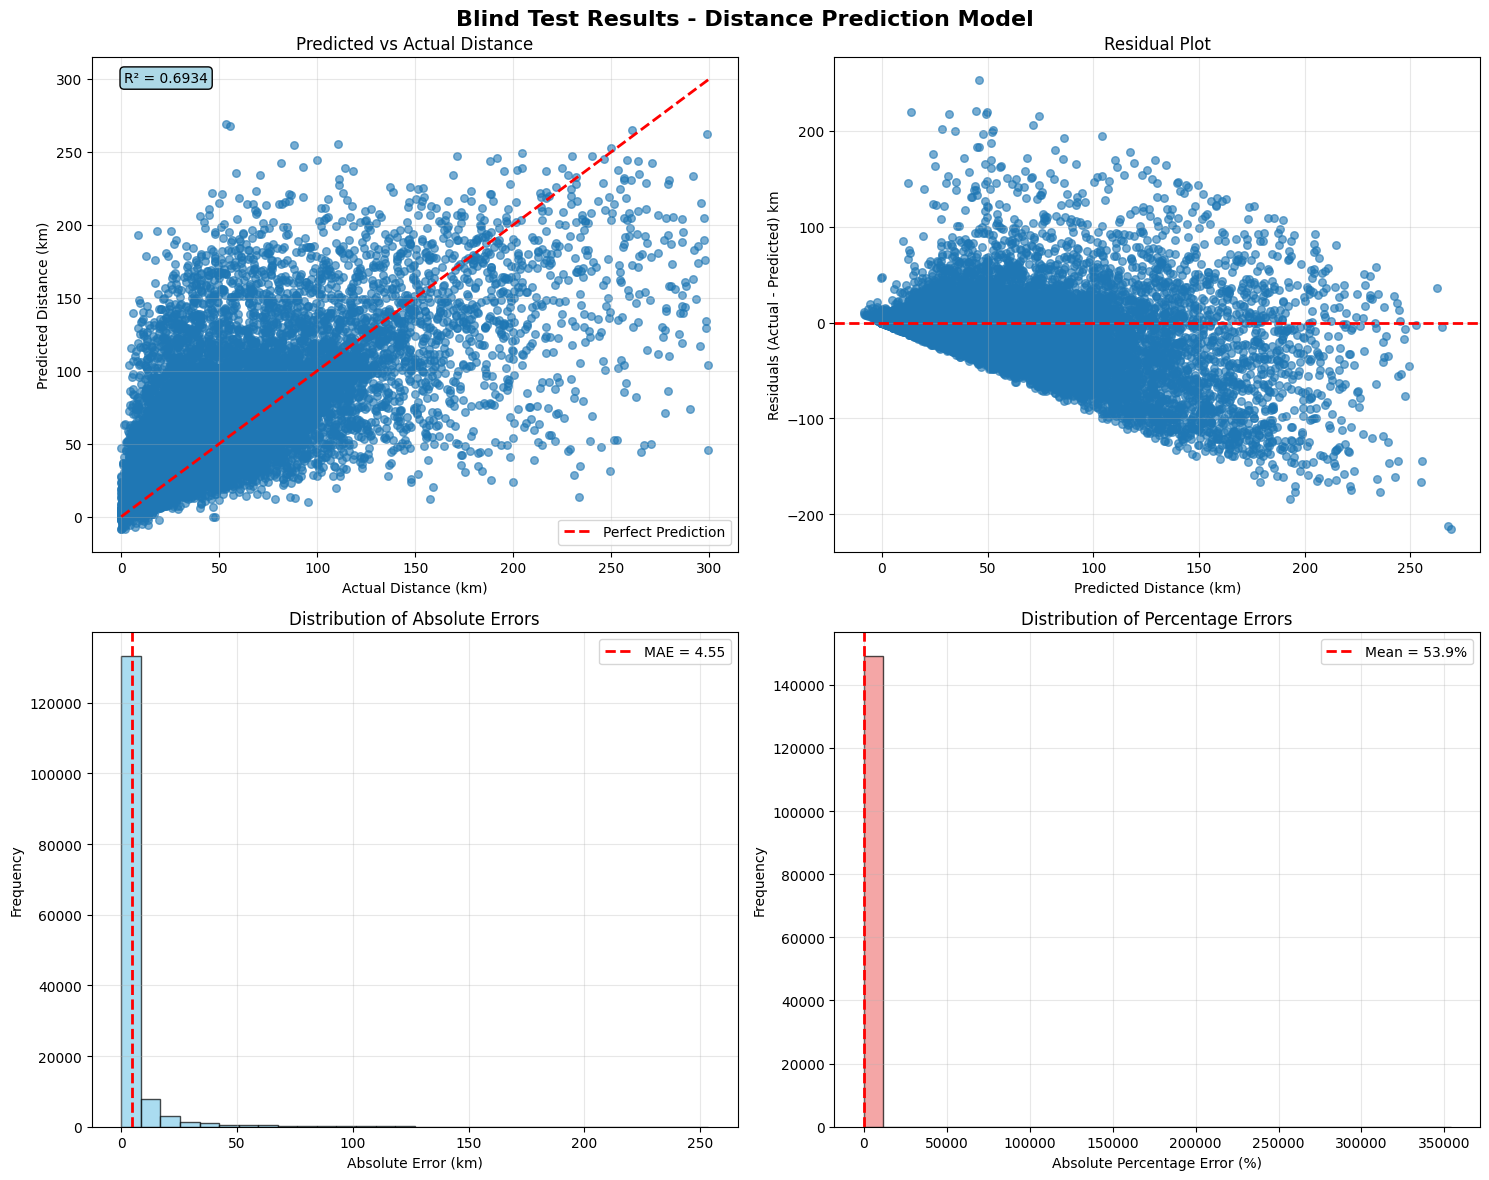


📊 PERFORMANCE BY TRIP DISTANCE RANGES:
------------------------------------------------------------
0-5 km     | Count: 22410 | MAE: 1.16km | R²: -4.683 | MAPE: 236.6%
5-10 km    | Count: 30980 | MAE: 1.86km | R²: -12.069 | MAPE: 25.2%
10-20 km   | Count: 44570 | MAE: 2.90km | R²: -5.552 | MAPE: 20.1%
20-50 km   | Count: 41019 | MAE: 6.01km | R²: -2.117 | MAPE: 19.7%
50+ km     | Count: 10224 | MAE: 21.50km | R²: 0.272 | MAPE: 24.7%

📋 BLIND TEST DATA SUMMARY:
🗂️  Data Source: 10 random .csv.out files from PROBE-202412
📅 Data Period: December 2024
🚖 Total Unique Taxis: 1517
🛣️  Total Trips Tested: 149203
⏱️  Processing Time Period: 2024-11-21 13:00:32 to 2024-12-31 23:57:45

✅ BLIND TEST COMPLETED SUCCESSFULLY!
📊 Model shows MODERATE performance with R² = 0.6934
🎯 Average prediction error: ±4.55 km (53.9%)

🚀 READY FOR INTEGRATION INTO YOUR TAXI RECOMMENDATION SYSTEM!


In [1]:
# %% [markdown]
# # Blind Test for Trip Distance Prediction Model
# This notebook performs blind testing on the saved XGBoost model using 10 random .csv.out files from PROBE-202412 data.
# This simulates real-world usage with completely unseen data from December 2024.

# %%
import pandas as pd
import numpy as np
import xgboost
import h3
import os
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# Load the trained model
try:
    model = xgboost.XGBRegressor()
    model.load_model('best_xgb_trip_distance.model')
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Make sure 'best_xgb_trip_distance.model' exists in your directory")

# %%
# Define data folder and column names (same as training data)
folder_path = '/Users/jul/Desktop/uni/Data Analytics/PROBE-202412'
columns = [
    'VehicleID',
    'gpsvalid',
    'lat',
    'lon',
    'timestamp',
    'speed',
    'heading',
    'for_hire_light',
    'engine_acc'
]

print(f"📁 Looking for .csv.out files in: {folder_path}")

# %%
# Get all .csv.out files and randomly select 10
try:
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv.out')]
    print(f"📊 Found {len(all_files)} .csv.out files in the folder")
    
    if len(all_files) == 0:
        raise FileNotFoundError("No .csv.out files found in the specified folder")
    
    # Randomly select 10 files (or all if less than 10)
    np.random.seed(42)  # For reproducibility
    selected_files = np.random.choice(all_files, size=min(10, len(all_files)), replace=False)
    
    print(f"🎯 Selected {len(selected_files)} files for blind testing:")
    for i, filename in enumerate(selected_files):
        print(f"   {i+1}. {filename}")
        
except Exception as e:
    print(f"❌ Error accessing folder: {e}")
    print("Make sure the folder path is correct and contains .csv.out files")

# %%
# Load and process the selected files (same pipeline as training data)
print("\n🔄 Processing selected files...")
print("=" * 50)

all_dfs = []

for i, filename in enumerate(selected_files):
    try:
        file_path = os.path.join(folder_path, filename)
        print(f"📥 Loading file {i+1}/{len(selected_files)}: {filename}")
        
        # Read the CSV file
        df = pd.read_csv(file_path, names=columns)
        all_dfs.append(df)
        
        print(f"   ✅ Loaded {len(df)} rows")
        
    except Exception as e:
        print(f"   ❌ Error loading {filename}: {e}")

# Combine all dataframes
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n📊 Combined dataset: {len(combined_df)} total rows")
else:
    raise ValueError("No files were successfully loaded")

# %%
# Clean and filter data (same as training pipeline)
print("\n🧹 Cleaning and filtering data...")
print("=" * 50)

# Remove rows with missing values
cleaned_df = combined_df.dropna()
print(f"📊 After removing NaN: {len(cleaned_df)} rows")

# Filter for valid GPS and engine data
cleaned_taxi_df = cleaned_df[
    (cleaned_df['gpsvalid'] == 1) &
    (cleaned_df['engine_acc'] == 1) &
    (cleaned_df['lat'].between(-90, 90)) &
    (cleaned_df['lon'].between(-180, 180)) &
    (cleaned_df['speed'] >= 0) &
    (cleaned_df['speed'] <= 180)  # Remove unrealistic speeds
].copy().reset_index(drop=True)

print(f"📊 After GPS/engine filtering: {len(cleaned_taxi_df)} rows")

# %%
# Filter to Bangkok Metropolitan Region
BKK_REGION_BOUNDS = {
    'min_lat': 13.4,
    'max_lat': 14.2,
    'min_lon': 99.9,
    'max_lon': 101.3
}

blind_test_df = cleaned_taxi_df[
    (cleaned_taxi_df['lat'] >= BKK_REGION_BOUNDS['min_lat']) &
    (cleaned_taxi_df['lat'] <= BKK_REGION_BOUNDS['max_lat']) &
    (cleaned_taxi_df['lon'] >= BKK_REGION_BOUNDS['min_lon']) &
    (cleaned_taxi_df['lon'] <= BKK_REGION_BOUNDS['max_lon'])
].copy()

print(f"📊 After Bangkok region filtering: {len(blind_test_df)} rows")

# %%
# Identify taxis and process timestamp
taxi_ids = blind_test_df[blind_test_df['for_hire_light'] == 1]['VehicleID'].unique()
taxis_df = blind_test_df[blind_test_df['VehicleID'].isin(taxi_ids)].copy()

print(f"🚖 Identified {len(taxi_ids)} unique taxis")
print(f"📊 Total taxi records: {len(taxis_df)} rows")

if len(taxis_df) == 0:
    raise ValueError("No taxi data found in the selected files")

# Convert timestamp and sort
taxis_df['timestamp'] = pd.to_datetime(taxis_df['timestamp'])
taxis_df = taxis_df.sort_values(by=['VehicleID', 'timestamp']).reset_index(drop=True)

# %%
# Filter to 2024 data only (same as training)
year_series = taxis_df['timestamp'].dt.year
taxis_df = taxis_df[year_series == 2024].copy()
print(f"📊 After 2024 filtering: {len(taxis_df)} rows")

if len(taxis_df) == 0:
    raise ValueError("No 2024 taxi data found in the selected files")

# %%
# Extract time features
taxis_df['hour'] = taxis_df['timestamp'].dt.hour
taxis_df['day_of_week'] = taxis_df['timestamp'].dt.dayofweek
taxis_df['is_weekend'] = (taxis_df['day_of_week'] >= 5).astype(int)

# Identify trips (same logic as training)
taxis_df['trip_start'] = (taxis_df['for_hire_light'].shift(1) == 1) & (taxis_df['for_hire_light'] == 0)
taxis_df['trip_start'] = taxis_df['trip_start'] & (taxis_df['VehicleID'].shift(1) == taxis_df['VehicleID'])
taxis_df['trip_id'] = taxis_df.groupby('VehicleID')['trip_start'].cumsum()
taxis_df.drop(columns=['trip_start'], inplace=True)

print(f"🚖 Trip identification completed")

# %%
# Calculate idle periods (same as training)
taxis_df['idle_start'] = (taxis_df['for_hire_light'].shift(1) == 0) & \
                         (taxis_df['for_hire_light'] == 1) & \
                         (taxis_df['VehicleID'].shift(1) == taxis_df['VehicleID'])
taxis_df['idle_period_id'] = taxis_df.groupby('VehicleID')['idle_start'].cumsum()
taxis_df.loc[taxis_df['trip_id'] == 0, 'idle_period_id'] = 0

# Calculate idle duration
idle_periods_df = taxis_df[taxis_df['for_hire_light'] == 1].copy()
idle_summary = idle_periods_df.groupby(['VehicleID', 'idle_period_id']).agg(
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max')
).reset_index()
idle_summary['idle_duration_minutes'] = (idle_summary['end_time'] - idle_summary['start_time']).dt.total_seconds() / 60 + 1

# Merge back idle duration
taxis_df = pd.merge(
    taxis_df,
    idle_summary[['VehicleID', 'idle_period_id', 'idle_duration_minutes']],
    on=['VehicleID', 'idle_period_id'],
    how='left'
)
taxis_df['idle_duration_minutes'].fillna(0, inplace=True)
taxis_df.drop(columns=['idle_start'], inplace=True)

print(f"⏰ Idle time calculation completed")

# %%
# Calculate trip distances using Haversine formula
def haversine_distance(lon1, lat1, lon2, lat2):
    """Calculate the great circle distance in kilometers between two points"""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r

# Calculate segment distances
taxis_df['lat_next'] = taxis_df.groupby(['VehicleID', 'trip_id'])['lat'].shift(-1)
taxis_df['lon_next'] = taxis_df.groupby(['VehicleID', 'trip_id'])['lon'].shift(-1)
taxis_df['segment_distance_km'] = haversine_distance(
    taxis_df['lon'], taxis_df['lat'], 
    taxis_df['lon_next'], taxis_df['lat_next']
)

# Calculate total trip distances
trip_distances = taxis_df.groupby(['VehicleID', 'trip_id'])['segment_distance_km'].sum().reset_index()
trip_distances.rename(columns={'segment_distance_km': 'total_trip_distance_km'}, inplace=True)
taxis_df = pd.merge(taxis_df, trip_distances, on=['VehicleID', 'trip_id'], how='left')

# Filter out unrealistic trips
taxis_df = taxis_df[
    (taxis_df['total_trip_distance_km'] <= 300) &
    (taxis_df['total_trip_distance_km'] > 0)
]

print(f"📊 After distance filtering: {len(taxis_df)} rows")

# %%
# Calculate trip features (same as training)
trip_groups = taxis_df.groupby(['VehicleID', 'trip_id'])

trip_start_time = trip_groups['timestamp'].min()
trip_end_time = trip_groups['timestamp'].max()
duration_seconds = (trip_end_time - trip_start_time).dt.total_seconds()
duration_minutes = duration_seconds / 60

pickup_hour = trip_start_time.dt.hour
pickup_dayofweek = trip_start_time.dt.dayofweek
average_speed = trip_groups['speed'].mean()

start_lat = trip_groups['lat'].first()
start_lon = trip_groups['lon'].first()
end_lat = trip_groups['lat'].last()
end_lon = trip_groups['lon'].last()

features_df = pd.DataFrame({
    'duration_minutes': duration_minutes,
    'pickup_hour': pickup_hour,
    'pickup_dayofweek': pickup_dayofweek,
    'average_speed': average_speed,
    'start_lat': start_lat,
    'start_lon': start_lon,
    'end_lat': end_lat,
    'end_lon': end_lon
})

features_df_to_merge = features_df.reset_index()
taxis_df = pd.merge(taxis_df, features_df_to_merge, on=['VehicleID', 'trip_id'], how='left')
taxis_df = taxis_df.dropna()

print(f"📊 After feature engineering: {len(taxis_df)} rows")

# %%
# Add H3 zones and temporal features (same as training)
def h3_cell(lat, lon, res=7):
    """Convert latitude/longitude to H3 cell"""
    try:
        if hasattr(h3, "geo_to_h3"):
            return h3.geo_to_h3(lat, lon, res)
        elif hasattr(h3, "latlng_to_cell"):
            return h3.latlng_to_cell(lat, lon, res)
        else:
            raise AttributeError("No suitable H3 function found.")
    except:
        return None

print("🗺️  Adding H3 zones...")
taxis_df['h3_start'] = taxis_df.apply(lambda row: h3_cell(row['start_lat'], row['start_lon'], 7), axis=1)
taxis_df['h3_end'] = taxis_df.apply(lambda row: h3_cell(row['end_lat'], row['end_lon'], 7), axis=1)

# Remove rows where H3 conversion failed
taxis_df = taxis_df[taxis_df['h3_start'].notna() & taxis_df['h3_end'].notna()]

# Add temporal features
taxis_df['pickup_month'] = taxis_df['timestamp'].dt.month
taxis_df['pickup_day'] = taxis_df['timestamp'].dt.day
taxis_df['pickup_weekofyear'] = taxis_df['timestamp'].dt.isocalendar().week

# Add idle time per trip
idle_time_per_trip = taxis_df.groupby(['VehicleID', 'trip_id'])['idle_duration_minutes'].sum().reset_index()
idle_time_per_trip.rename(columns={'idle_duration_minutes': 'total_idle_minutes'}, inplace=True)
taxis_df = pd.merge(taxis_df, idle_time_per_trip, on=['VehicleID', 'trip_id'], how='left')

print(f"📊 Final processed data: {len(taxis_df)} rows")

# %%
# Prepare blind test features and targets
print("\n🔬 Preparing Blind Test Data...")
print("=" * 50)

# Get unique trips for testing
distance_features = [
    'VehicleID', 'trip_id',
    'duration_minutes', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day', 'pickup_weekofyear',
    'average_speed', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'h3_start', 'h3_end', 'total_idle_minutes'
]

X_blind = taxis_df[distance_features].drop_duplicates(subset=['VehicleID', 'trip_id'])
y_blind = taxis_df[['VehicleID', 'trip_id', 'total_trip_distance_km']].drop_duplicates(subset=['VehicleID', 'trip_id'])

# Merge to align
blind_test_data = pd.merge(X_blind, y_blind, on=['VehicleID', 'trip_id'])

# Convert H3 to integers for model
blind_test_data['h3_start'] = blind_test_data['h3_start'].apply(lambda x: int(x, 16))
blind_test_data['h3_end'] = blind_test_data['h3_end'].apply(lambda x: int(x, 16))

print(f"🎯 Prepared {len(blind_test_data)} unique trips for blind testing")
print(f"📊 Trip distance range: {blind_test_data['total_trip_distance_km'].min():.2f} - {blind_test_data['total_trip_distance_km'].max():.2f} km")
print(f"📊 Mean trip distance: {blind_test_data['total_trip_distance_km'].mean():.2f} km")

# %%
# Perform blind test predictions
print("\n🔮 Making Predictions on Blind Test Data...")
print("=" * 50)

if len(blind_test_data) == 0:
    raise ValueError("No trips available for blind testing")

# Prepare features for model (remove ID columns)
X_test_features = blind_test_data.drop(['VehicleID', 'trip_id', 'total_trip_distance_km'], axis=1)
y_true = blind_test_data['total_trip_distance_km']

# Make predictions
try:
    y_pred = model.predict(X_test_features)
    print(f"✅ Successfully made predictions for {len(y_pred)} trips")
except Exception as e:
    print(f"❌ Error making predictions: {e}")
    raise

# %%
# Calculate evaluation metrics
print("\n📊 BLIND TEST EVALUATION RESULTS")
print("=" * 60)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"📈 PERFORMANCE METRICS:")
print(f"   🎯 Mean Absolute Error (MAE): {mae:.3f} km")
print(f"   🎯 Root Mean Squared Error (RMSE): {rmse:.3f} km")
print(f"   🎯 R² Score: {r2:.4f}")
print(f"   📊 Mean actual distance: {y_true.mean():.2f} km")
print(f"   📊 Mean predicted distance: {y_pred.mean():.2f} km")

# Calculate percentage errors
percentage_errors = np.abs(y_true - y_pred) / y_true * 100
print(f"   📊 Mean Absolute Percentage Error: {percentage_errors.mean():.1f}%")
print(f"   📊 Median Absolute Percentage Error: {np.median(percentage_errors):.1f}%")

# %%
# Show detailed individual predictions
print(f"\n🔍 SAMPLE INDIVIDUAL PREDICTIONS:")
print("-" * 80)
print(f"{'Trip':<6} {'Actual (km)':<12} {'Predicted (km)':<15} {'Error (km)':<12} {'Error (%)':<10}")
print("-" * 80)

sample_size = min(20, len(blind_test_data))
sample_indices = np.random.choice(len(blind_test_data), size=sample_size, replace=False)

for i, idx in enumerate(sample_indices):
    actual = y_true.iloc[idx]
    predicted = y_pred[idx]
    error_abs = abs(actual - predicted)
    error_pct = error_abs / actual * 100
    
    print(f"{i+1:<6} {actual:<12.2f} {predicted:<15.2f} {error_abs:<12.2f} {error_pct:<10.1f}")

# %%
# Visualize results
print(f"\n📈 CREATING VISUALIZATION...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Blind Test Results - Distance Prediction Model', fontsize=16, fontweight='bold')

# Plot 1: Predicted vs Actual
axes[0,0].scatter(y_true, y_pred, alpha=0.6, s=30)
perfect_line = np.linspace(y_true.min(), y_true.max(), 100)
axes[0,0].plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Distance (km)')
axes[0,0].set_ylabel('Predicted Distance (km)')
axes[0,0].set_title('Predicted vs Actual Distance')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add R² annotation
axes[0,0].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0,0].transAxes, 
               bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

# Plot 2: Residuals
residuals = y_true - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.6, s=30)
axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0,1].set_xlabel('Predicted Distance (km)')
axes[0,1].set_ylabel('Residuals (Actual - Predicted) km')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Error distribution
axes[1,0].hist(np.abs(residuals), bins=30, alpha=0.7, edgecolor='black', color='skyblue')
axes[1,0].axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE = {mae:.2f}')
axes[1,0].set_xlabel('Absolute Error (km)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Absolute Errors')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Percentage error distribution
axes[1,1].hist(percentage_errors, bins=30, alpha=0.7, edgecolor='black', color='lightcoral')
axes[1,1].axvline(percentage_errors.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean = {percentage_errors.mean():.1f}%')
axes[1,1].set_xlabel('Absolute Percentage Error (%)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Percentage Errors')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Summary statistics by trip distance ranges
print(f"\n📊 PERFORMANCE BY TRIP DISTANCE RANGES:")
print("-" * 60)

# Define distance ranges
ranges = [(0, 5), (5, 10), (10, 20), (20, 50), (50, float('inf'))]
range_names = ['0-5 km', '5-10 km', '10-20 km', '20-50 km', '50+ km']

for (min_dist, max_dist), range_name in zip(ranges, range_names):
    mask = (y_true >= min_dist) & (y_true < max_dist)
    if mask.sum() > 0:
        range_mae = mean_absolute_error(y_true[mask], y_pred[mask])
        range_r2 = r2_score(y_true[mask], y_pred[mask])
        range_mape = (np.abs(y_true[mask] - y_pred[mask]) / y_true[mask] * 100).mean()
        
        print(f"{range_name:<10} | Count: {mask.sum():<5} | MAE: {range_mae:.2f}km | R²: {range_r2:.3f} | MAPE: {range_mape:.1f}%")

# %%
# Data source summary
print(f"\n📋 BLIND TEST DATA SUMMARY:")
print("=" * 60)
print(f"🗂️  Data Source: {len(selected_files)} random .csv.out files from PROBE-202412")
print(f"📅 Data Period: December 2024")
print(f"🚖 Total Unique Taxis: {blind_test_data['VehicleID'].nunique()}")
print(f"🛣️  Total Trips Tested: {len(blind_test_data)}")
print(f"⏱️  Processing Time Period: {taxis_df['timestamp'].min()} to {taxis_df['timestamp'].max()}")

print(f"\n✅ BLIND TEST COMPLETED SUCCESSFULLY!")
print(f"📊 Model shows {'GOOD' if r2 > 0.7 else 'MODERATE' if r2 > 0.5 else 'POOR'} performance with R² = {r2:.4f}")
print(f"🎯 Average prediction error: ±{mae:.2f} km ({percentage_errors.mean():.1f}%)")

print(f"\n🚀 READY FOR INTEGRATION INTO YOUR TAXI RECOMMENDATION SYSTEM!")